import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
import re

sns.set_style("whitegrid")

Load Dataset

In [2]:
df=pd.read_csv(r"C:\Datasets\dataset.csv")

In [3]:
# Display first 5 rows
df.head()

,Unnamed: 0,source_text,plagiarized_text,label
0,0,Researchers have discovered a new species of b...,Scientists have found a previously unknown but...,1
1,1,The moon orbits the Earth in approximately 27....,Our natural satellite takes around 27.3 days t...,1
2,2,Water is composed of two hydrogen atoms and on...,H2O consists of 2 hydrogen atoms and 1 oxygen ...,1
3,3,The history of Rome dates back to 753 BC.,Rome has a long history that can be traced bac...,1
4,4,Pluto was once considered the ninth planet in ...,"In the past, Pluto was classified as the ninth...",1


Data Inspection

In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (370, 4)


In [5]:
print("\nColumn Names:")
print(df.columns)


Column Names:
Index(['Unnamed: 0', 'source_text', 'plagiarized_text', 'label'], dtype='object')


In [6]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 370 entries, 0 to 369
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        370 non-null    int64 
 1   source_text       370 non-null    object
 2   plagiarized_text  370 non-null    object
 3   label             370 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 11.7+ KB


In [9]:
print("\nStatistical Summary:")
df.describe(include="all")


Statistical Summary:


,Unnamed: 0,source_text,plagiarized_text,label
count,370.000000,370,370,370.000000
unique,NaN,365,367,NaN
top,NaN,The Great Barrier Reef is located off the coas...,"From space, the Great Wall of China is visible.",NaN
freq,NaN,2,2,NaN
mean,206.591892,NaN,NaN,0.494595
std,117.774570,NaN,NaN,0.500648
min,0.000000,NaN,NaN,0.000000
25%,112.500000,NaN,NaN,0.000000
50%,211.500000,NaN,NaN,0.000000
75%,308.750000,NaN,NaN,1.000000


In [10]:
print("Missing Values:")
print(df.isnull().sum())

print("\nMissing Values Percentage:")
print((df.isnull().mean() * 100).round(2))

Missing Values:
Unnamed: 0          0
source_text         0
plagiarized_text    0
label               0
dtype: int64

Missing Values Percentage:
Unnamed: 0          0.0
source_text         0.0
plagiarized_text    0.0
label               0.0
dtype: float64


In [11]:
print("Exact Duplicate Rows:", df.duplicated().sum())

Exact Duplicate Rows: 0


Analyze the target variable

In [12]:
print(df["label"].value_counts())

print("\nPercentage Distribution:")
print(df["label"].value_counts(normalize=True) * 100)

label
0    187
1    183
Name: count, dtype: int64

Percentage Distribution:
label
0    50.540541
1    49.459459
Name: proportion, dtype: float64


Visualize class distribution

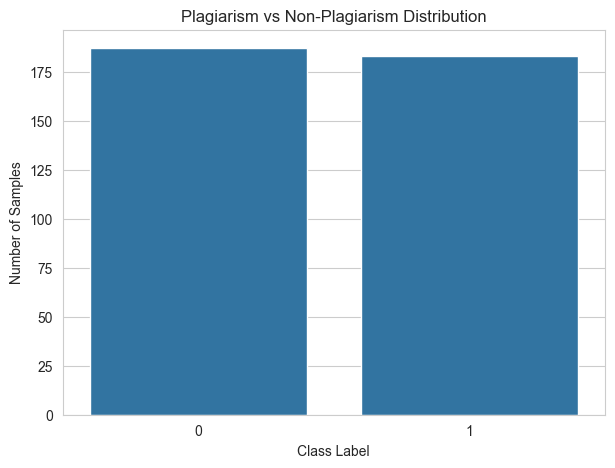

In [13]:
# Visulaize class distribution
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="label")

plt.title("Plagiarism vs Non-Plagiarism Distribution")
plt.xlabel("Class Label")
plt.ylabel("Number of Samples")

plt.show()

Analyze text length

In [14]:
text_columns = ["source_text", "plagiarized_text"]

for col in text_columns:
    df[col] = df[col].astype("string")

    df[col + "_char_length"] = df[col].str.len()

    df[col + "_word_count"] = (
        df[col].str.split().str.len()
    )


In [16]:
df[
    [
        "source_text_char_length",
        "plagiarized_text_char_length",
        "source_text_word_count",
        "plagiarized_text_word_count"
    ]
].describe()

,source_text_char_length,plagiarized_text_char_length,source_text_word_count,plagiarized_text_word_count
count,370.0,370.0,370.000000,370.000000
mean,45.291892,48.402703,7.037838,7.724324
std,11.681927,11.878905,2.394365,2.152632
min,14.0,16.0,3.000000,3.000000
25%,38.0,42.0,5.000000,6.000000
50%,45.5,48.0,7.000000,7.000000
75%,53.0,55.0,9.000000,9.000000
max,80.0,86.0,14.000000,15.000000


Visualize word counts:

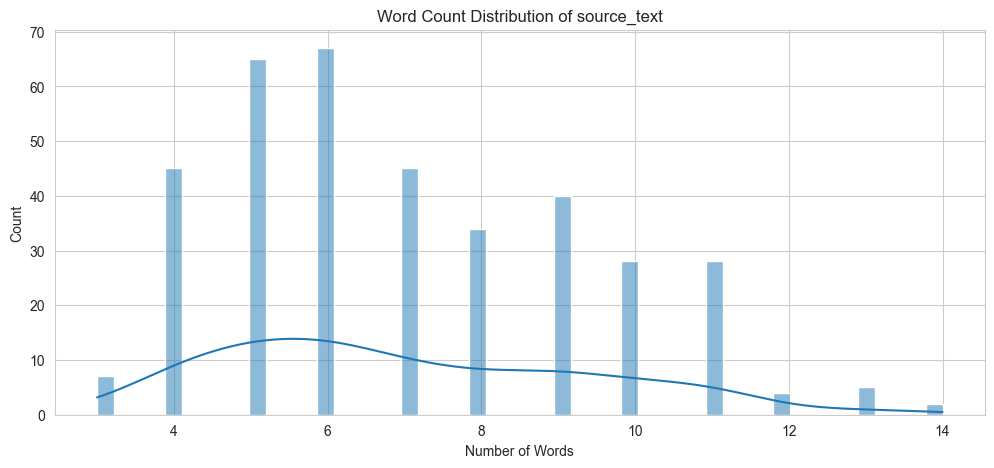

In [19]:
plt.figure(figsize=(12, 5))

sns.histplot(
    data=df,
    x="source_text_word_count",
    bins=50,
    kde=True
)

plt.title("Word Count Distribution of source_text")
plt.xlabel("Number of Words")

plt.show()

Compare both 

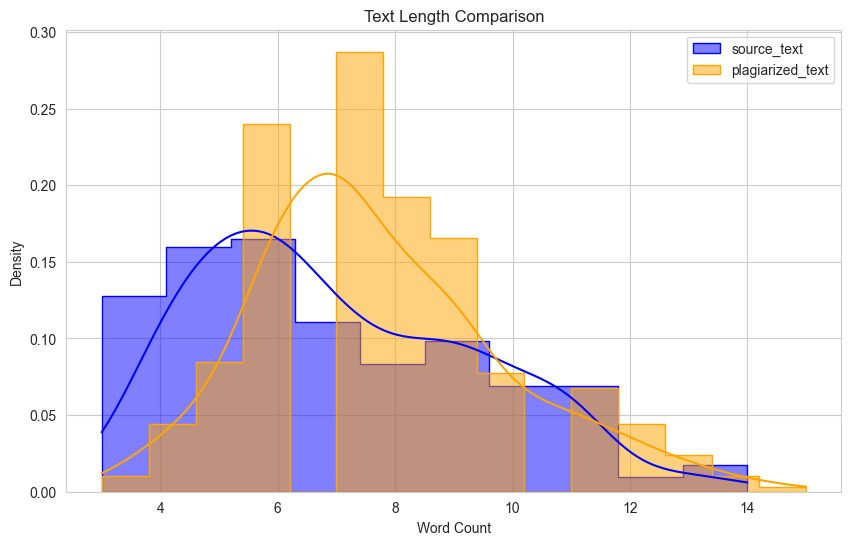

In [21]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["source_text_word_count"],
    color="blue",
    label="source_text",
    kde=True,
    stat="density",
    element="step"
)

sns.histplot(
    df["plagiarized_text_word_count"],
    color="orange",
    label="plagiarized_text",
    kde=True,
    stat="density",
    element="step"
)

plt.title("Text Length Comparison")
plt.xlabel("Word Count")
plt.legend()

plt.show()

Compare text length by plagiarism class

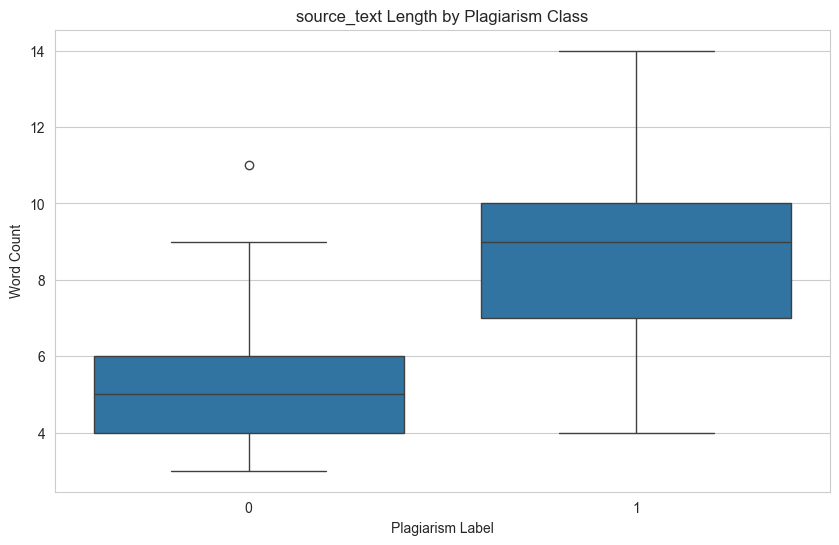

In [23]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="label",
    y="source_text_word_count"
)

plt.title("source_text Length by Plagiarism Class")
plt.xlabel("Plagiarism Label")
plt.ylabel("Word Count")

plt.show()

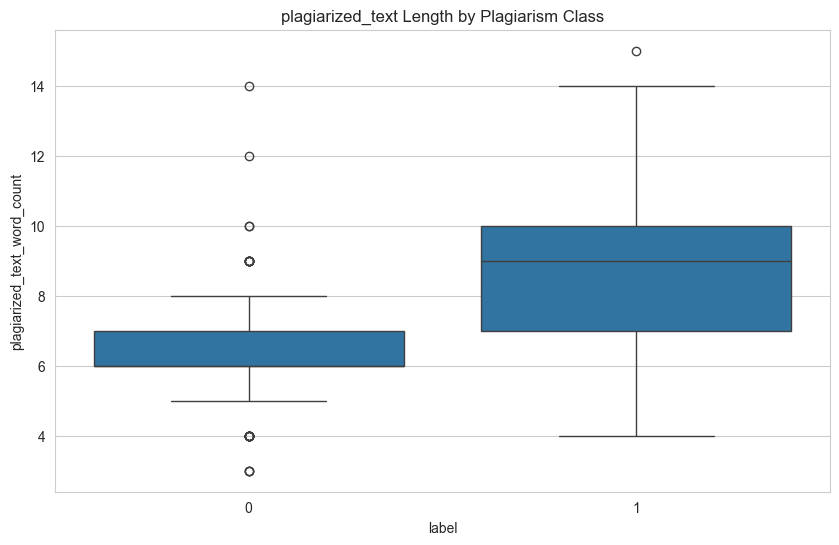

In [24]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="label",
    y="plagiarized_text_word_count"
)

plt.title("plagiarized_text Length by Plagiarism Class")
plt.show()

DATA PREPROCESSING

Clean Text

In [31]:
import nltk
nltk.download("popular")
from sklearn.metrics.pairwise import cosine_similarity
import string
from nltk.corpus import stopwords
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer

[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to C:\Users\PRINCE
[nltk_data]    |     COMPUTER\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping corpora\cmudict.zip.
[nltk_data]    | Downloading package gazetteers to C:\Users\PRINCE
[nltk_data]    |     COMPUTER\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping corpora\gazetteers.zip.
[nltk_data]    | Downloading package genesis to C:\Users\PRINCE
[nltk_data]    |     COMPUTER\AppData\Roaming\nltk_data...
[nltk_data]    | Error downloading 'genesis' from
[nltk_data]    |     <https://raw.githubusercontent.com/nltk/nltk_data
[nltk_data]    |     /gh-pages/packages/corpora/genesis.zip>:
[nltk_data]    |     <urlopen error [WinError 10054] An existing
[nltk_data]    |     connection was forcibly closed by the remote
[nltk_data]    |     host>


In [33]:
def preprocess_text(text):
    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    # Convert to lowercase
    text = text.lower()
    # Remove stop words
    stop_words = set(stopwords.words("english"))
    text = " ".join(word for word in text.split() if word not in stop_words)
    return text
df["source_text"] = df["source_text"].apply(preprocess_text)
df["plagiarized_text"] = df["plagiarized_text"].apply(preprocess_text)

Vectorization

In [35]:

tfidf_vectorizer = TfidfVectorizer()
X = tfidf_vectorizer.fit_transform(df["source_text"] + " " + df["plagiarized_text"])

In [37]:
y = df["label"]

Train Test Split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

applying logistic regression

In [39]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train,y_train)

y_pred = lr.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Classification Report:")
print(classification_rep)
print("Confusion Matrix")
print(cm)

Accuracy: 0.8243243243243243
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.86      0.82        35
           1       0.86      0.79      0.83        39

    accuracy                           0.82        74
   macro avg       0.83      0.83      0.82        74
weighted avg       0.83      0.82      0.82        74

Confusion Matrix
[[30  5]
 [ 8 31]]


Random Forest Model

In [40]:
from sklearn.ensemble import RandomForestClassifier
# Instantiate the model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
# Fit the model
rf.fit(X_train, y_train)
# Make predictions
y_pred = rf.predict(X_test)
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
# Generate classification report
classification_rep = classification_report(y_test, y_pred)
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Print results
print("Accuracy:", accuracy)
print("Classification Report:")
print(classification_rep)
print("Confusion Matrix:")
print(cm)

Accuracy: 0.7972972972972973
Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.97      0.82        35
           1       0.96      0.64      0.77        39

    accuracy                           0.80        74
   macro avg       0.83      0.81      0.79        74
weighted avg       0.84      0.80      0.79        74

Confusion Matrix:
[[34  1]
 [14 25]]


Naiv Bays Model

In [42]:
from sklearn.naive_bayes import MultinomialNB
# Instantiate the model
nb = MultinomialNB()
# Fit the model
nb.fit(X_train, y_train)
# Make predictions
y_pred = nb.predict(X_test)
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
# Generate classification report
classification_rep = classification_report(y_test, y_pred)
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Print results
print("Accuracy:", accuracy)
print("Classification Report:")
print(classification_rep)
print("Confusion Matrix:")
print(cm)

Accuracy: 0.8648648648648649
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86        35
           1       0.87      0.87      0.87        39

    accuracy                           0.86        74
   macro avg       0.86      0.86      0.86        74
weighted avg       0.86      0.86      0.86        74

Confusion Matrix:
[[30  5]
 [ 5 34]]


SVM

In [43]:
from sklearn.svm import SVC

# Instantiate the model
svm = SVC(kernel='linear', random_state=42)
# Fit the model
svm.fit(X_train, y_train)
# Make predictions
y_pred = svm.predict(X_test)
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
# Generate classification report
classification_rep = classification_report(y_test, y_pred)
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Print results
print("Accuracy:", accuracy)
print("Classification Report:")
print(classification_rep)
print("Confusion Matrix:")
print(cm)

Accuracy: 0.8783783783783784
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.89      0.87        35
           1       0.89      0.87      0.88        39

    accuracy                           0.88        74
   macro avg       0.88      0.88      0.88        74
weighted avg       0.88      0.88      0.88        74

Confusion Matrix:
[[31  4]
 [ 5 34]]


Save SVM And Vectorizer

In [44]:
import pickle

pickle.dump(svm,open("svm.pkl",'wb'))
pickle.dump(tfidf_vectorizer, open('tfidf_vectorizer.pkl','wb'))